In [1]:
import os,pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC,SVC
from sklearn.metrics import f1_score,make_scorer,accuracy_score,precision_score,recall_score
from sklearn.ensemble import RandomForestClassifier
import shap

from project_package.visualization import Model_Visualizer
from project_package import utility,evaluation,modeling

g:\Python\envs\learning_env\lib\site-packages\dask\dataframe\__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [2]:
# choose to test either full version or lite version
use_lite_version = True
if use_lite_version:
    base_directory = 'supervised_lite'
else:
    base_directory = 'supervised'

#### Problem 1: Classification (booking completion vs cancellation)

In [4]:
files = os.listdir(base_directory)

file = [item for item in files if 'target_completed_.pkl' in item][-1]

model_path = os.path.join(base_directory, file)

with open(model_path, "rb") as f:
    model = pickle.load(f)
model

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x00000166DDB07CA0>),
                                                 ('cat',
                                                  Pipeline(steps=[('imp',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ord',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x0000016683C4EAF0>)])),
                ('clf',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, n_jobs=-1,
                                        random_state=42))])

Load the train and test data

In [5]:
split_df = pd.read_csv(os.path.join(base_directory, 'split_assignments_classification.csv'))

if use_lite_version:
    model_data =pd.read_csv('ncr_ride_bookings_with_weather_filled_scaled_short__top20_s30.csv')
else:
    model_data =pd.read_csv('ncr_ride_bookings_with_weather_filled_scaled_short.csv')

In [6]:
if use_lite_version:
    # train data
    train_data = model_data.loc[split_df.loc[split_df.split=='train'].index]
    train_data = modeling.drop_unnecessary_cols(train_data,'_target_completed_')
    # validation data
    test_data = model_data.loc[split_df.loc[split_df.split=='valid'].index]
    test_data = modeling.drop_unnecessary_cols(test_data,'_target_completed_')
else:
    # train data
    train_data = modeling.make_binary_target(model_data.loc[split_df.loc[split_df.split=='train'].index])[0]
    train_data = modeling.drop_unnecessary_cols(train_data,'_target_completed_')
    # validation data
    test_data = modeling.make_binary_target(model_data.loc[split_df.loc[split_df.split=='valid'].index])[0]
    test_data = modeling.drop_unnecessary_cols(test_data,'_target_completed_')

y_train = split_df.loc[split_df.split=='train']['_target_completed_']
y_test = split_df.loc[split_df.split=='valid']['_target_completed_']

In [7]:
## check model score
prediction_df = pd.read_csv(f'{base_directory}/cls_best_rf_preds.csv')

print('---------on training dataset--------------')
print('precision from model:',precision_score(y_train,model.predict(train_data)))
print('precision from model(macro):',precision_score(y_train,model.predict(train_data),average='macro'))
print()
print('recall from model:',recall_score(y_train,model.predict(train_data)))
print('recall from model(macro):',recall_score(y_train,model.predict(train_data),average='macro'))

print()
print('---------on test dataset--------------')
print('precision from model:',precision_score(y_test,model.predict(test_data)))
print('precision from model(macro):',precision_score(y_test,model.predict(test_data),average='macro'))
print('precision from file:',precision_score(y_test,prediction_df.y_pred))
print('precision from file(macro):',precision_score(y_test,prediction_df.y_pred,average='macro'))
print()
print('recall from model:',recall_score(y_test,model.predict(test_data)))
print('recall from model(macro):',recall_score(y_test,model.predict(test_data),average='macro'))
print('recall from file:',recall_score(y_test,prediction_df.y_pred))
print('recall from file(macro):',recall_score(y_test,prediction_df.y_pred,average='macro'))

---------on training dataset--------------
precision from model: 0.6225767260049654
precision from model(macro): 0.5028176444985457

recall from model: 0.5402704561081825
recall from model(macro): 0.502972499965548

---------on test dataset--------------
precision from model: 0.6200341491178144
precision from model(macro): 0.5183504078922405
precision from file: 0.9181494661921709
precision from file(macro): 0.9528592634828257

recall from model: 0.9987165383204987
recall from model(macro): 0.5001061004495104
recall from file: 0.9933993399339934
recall from file(macro): 0.9244591674243703


In [24]:
classify_vis_obj = Model_Visualizer(
    # train_data.to_numpy(),
    # test_data.to_numpy(),
    train_data,
    test_data,
    y_train,
    y_test,
    # feature_names=train_data.columns
    feature_names = model[0].get_feature_names_out()
    )

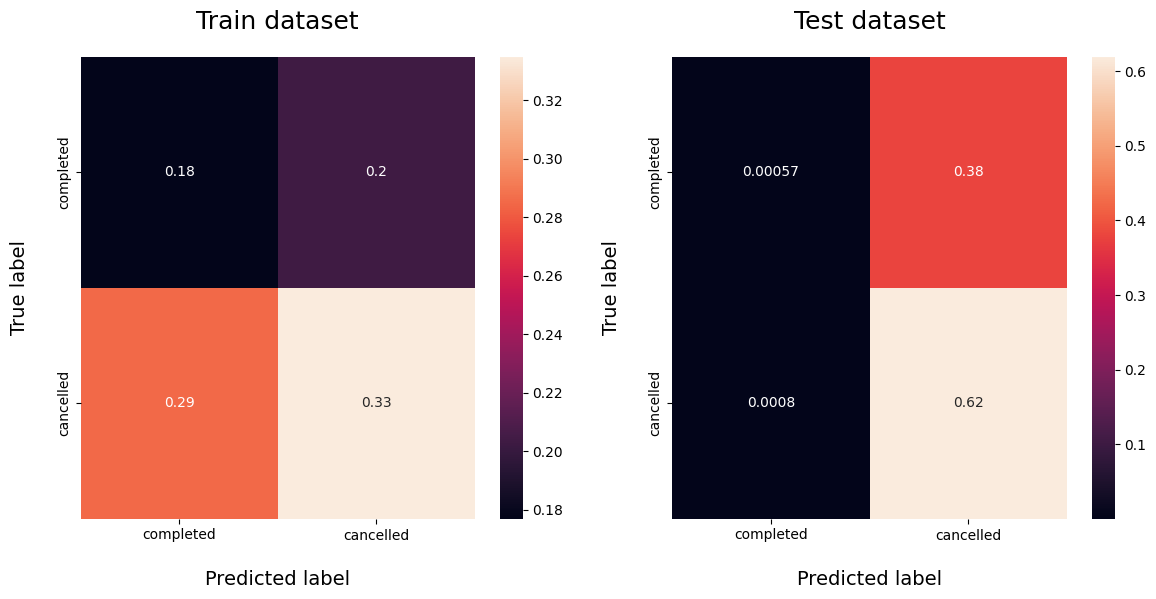

In [25]:
# confusion matrix
classify_vis_obj.confusion_matrix(model,['completed','cancelled'],normalize=True)  # are these label correct?

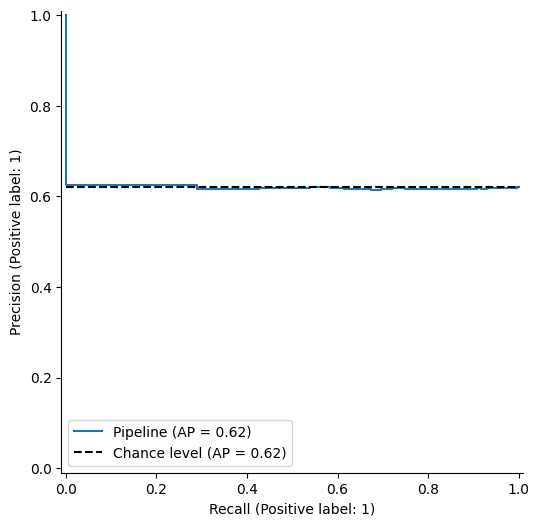

In [76]:
#precision curve
classify_vis_obj.precision_recall_curve(model)

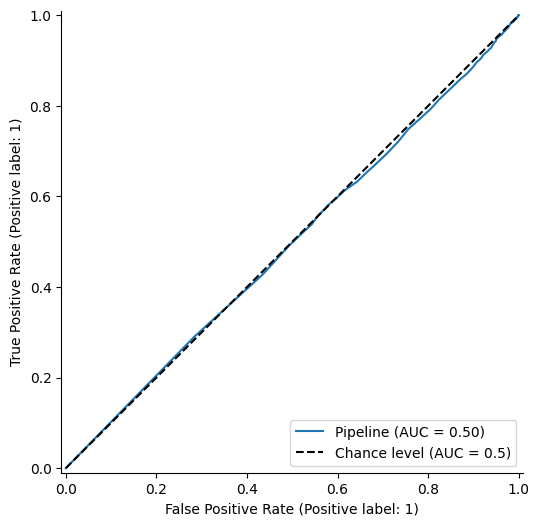

In [77]:
#ROC curve
classify_vis_obj.ROC_curve(model)

Feature Importance and Ablation Analysis

<Axes: title={'center': 'Feature Importance plot'}, xlabel='Importance', ylabel='Features'>

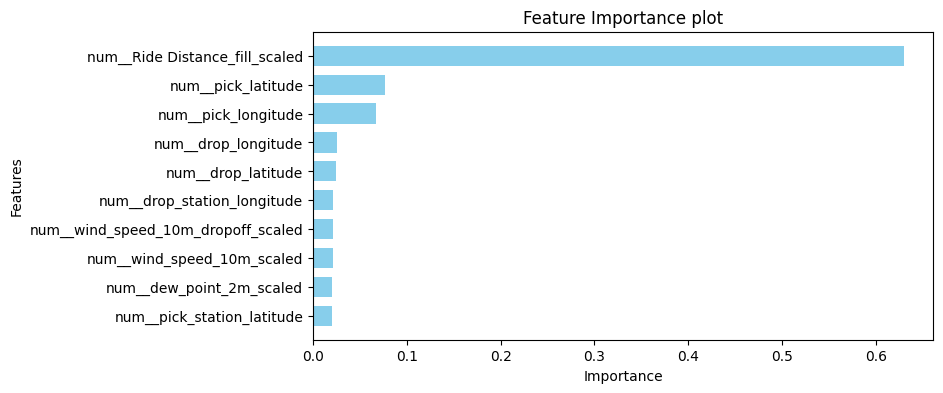

In [26]:
classify_vis_obj.feature_importance_plot(model.named_steps['clf'].feature_importances_,normalize=False,top_n=10)

In [80]:
train_permute,test_permute = evaluation.permutation_test(
    model,train_data,test_data,
    target_col = '_target_completed_',scorer='f1_macro',random_state=0,n_jobs=-1
    )

<Axes: title={'center': 'train data'}, xlabel='Decrease in metric score'>

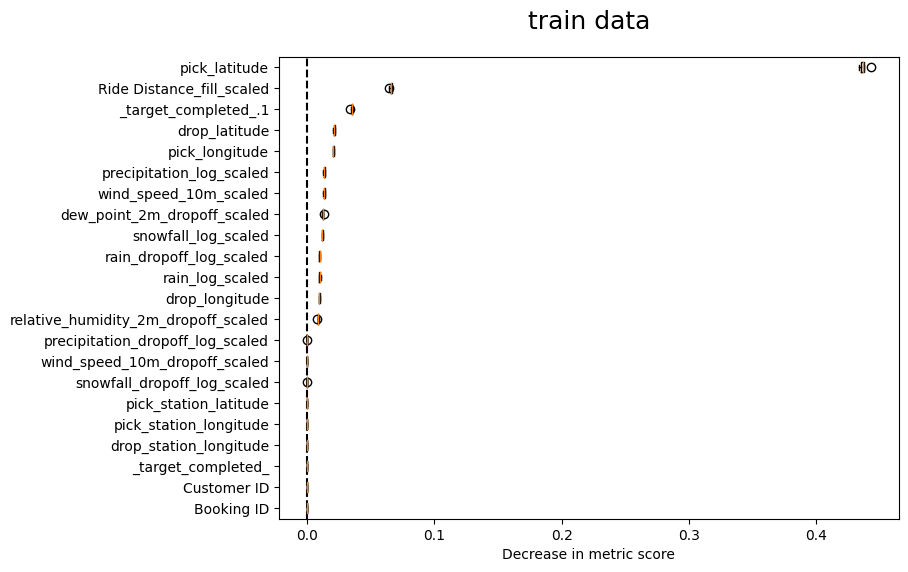

In [81]:
classify_vis_obj.permutation_importance_plot(train_permute,figsize=(8,6),title='train data')

<Axes: title={'center': 'test data'}, xlabel='Decrease in metric score'>

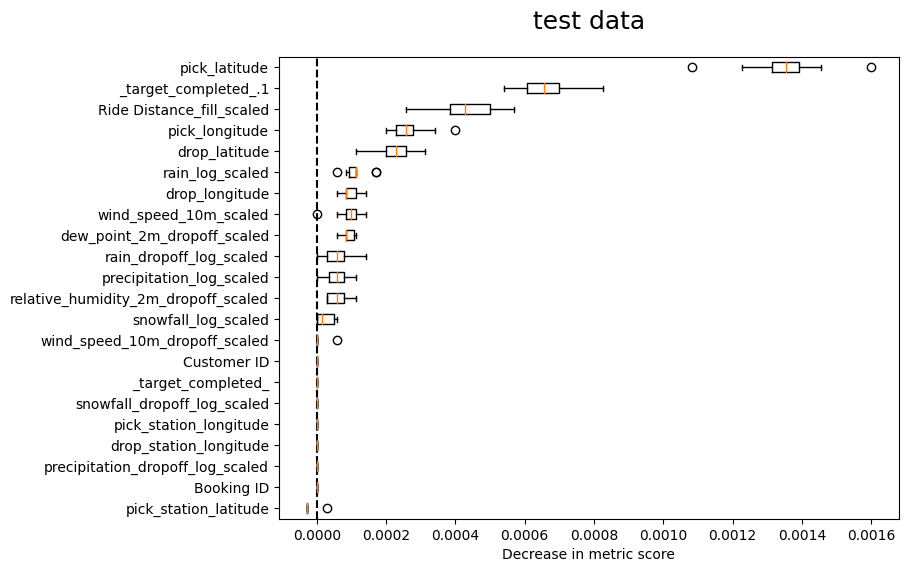

In [82]:
classify_vis_obj.permutation_importance_plot(test_permute,figsize=(8,6),title='test data')

<Axes: title={'center': 'Ablation test'}, xlabel='f1 score'>

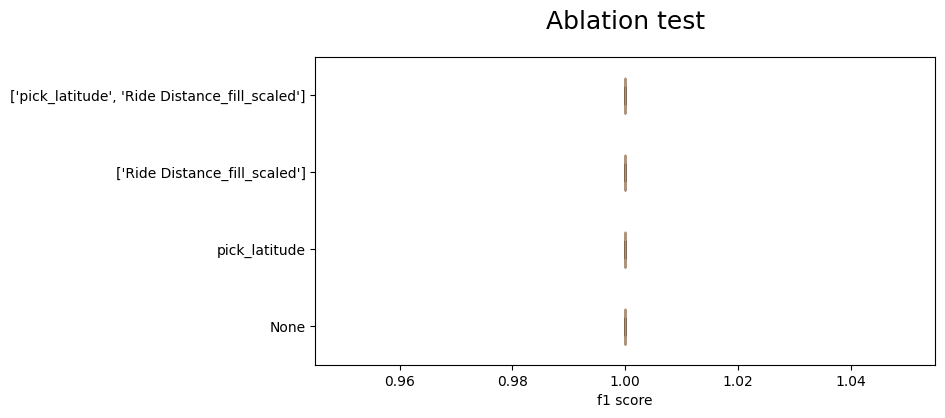

In [84]:
remove_features = ['pick_latitude',
                    ['Ride Distance_fill_scaled'],
                    ['pick_latitude','Ride Distance_fill_scaled']
                    ]

score_array,eval_df = evaluation.ablation_test(
    model,
    train_data = train_data,
    test_data = test_data,
    target_col = '_target_completed_',
    scorer=make_scorer(f1_score,average='macro'),
    remove_features = remove_features,
    n_jobs=-1
)

classify_vis_obj.box_plot(score_array.T,labels=['None'] + remove_features,title='Ablation test',xlabel='f1 score')

Sensivity analysis

In [85]:
# grids = {
    # 'clf__n_estimators':np.linspace(20,250,24),
    # 'clf__max_depth':np.linspace(1,12,12)
    # }

# grids = {
    # 'clf__n_estimators':np.linspace(100,200,11),
    # 'clf__max_depth':np.linspace(1,6,6)
    # }

grids = {
    'clf__n_estimators':np.linspace(100,200,2).astype(int),
    'clf__max_depth':np.linspace(1,2,2).astype(int)
    }
eval_df = evaluation.supervised_sensivity_test(
    model,train_data,
    target_col='_target_completed_',
    param_grid=grids,
    scoring = 'f1_macro',
    verbose=0,
    n_jobs=-1
    )
eval_df

,clf__max_depth,clf__n_estimators,f1_macro,f1_macro_std
0,1,100,1.0,0.0
1,1,200,1.0,0.0
2,2,100,1.0,0.0
3,2,200,1.0,0.0


In [86]:
classify_vis_obj.sensivity_plot(eval_df,
               'f1_macro',
               param1 = ('clf__n_estimators','clf__max_depth',eval_df.clf__max_depth.unique()[0]),
               param2 = ('clf__max_depth','clf__n_estimators',eval_df.clf__n_estimators.unique()[1])
               )

Learning curve

In [87]:
cross_scores,sample_range,result_df = evaluation.learning_curve_test(
    model,train_data,
    target_col='_target_completed_',
    sample_range=np.linspace(1000,35000,35).astype(int),
    scorer = make_scorer(f1_score,average='macro'),
    n_jobs=-1
    )

<Axes: title={'center': 'Learning curve analysis'}, xlabel='No. of training records', ylabel='F1 score'>

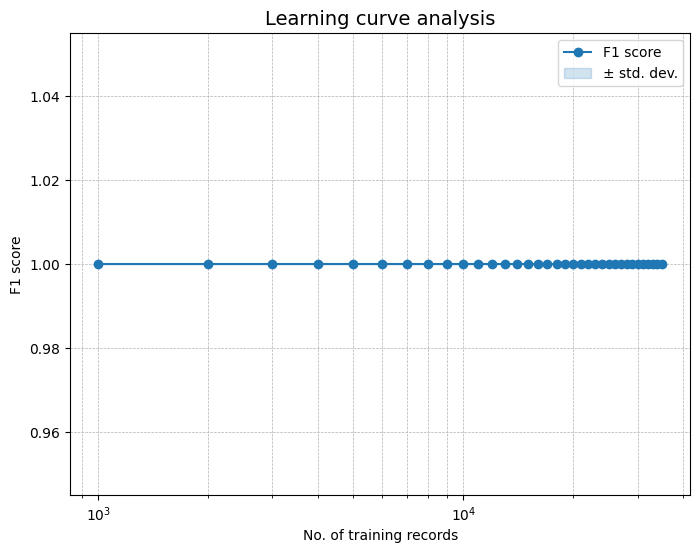

In [88]:
classify_vis_obj.learning_curve_plot(sample_range,result_df.score_mean,result_df.score_std,log_sample=True)

Failure analysis (classification)

In [89]:
ex_df,ex_info_df = evaluation.get_worst_examples(
    model,test_data,
    get_n=1,
    target_col='_target_completed_',
    problem_type='classification',
    get_random_err=False,
    random_state=0
)

test_shap_values,_ = evaluation.shap_analysis(
    model,
    shap.TreeExplainer,
    shap.sample(train_data,nsamples=1000), # recommended number in documentation
    shap.sample(test_data),
    target_col = '_target_completed_'
)

ex_shap_values,_ = evaluation.shap_analysis(
    model,
    shap.TreeExplainer,
    shap.sample(train_data,nsamples=1000),  # recommended number in documentation
    ex_df,
    target_col = '_target_completed_'
)


100%|===================| 199/200 [00:21<00:00]        

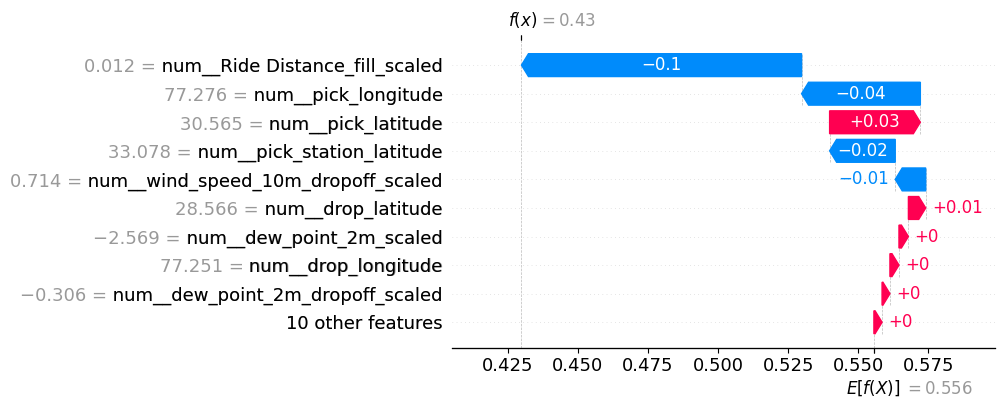

In [90]:
classify_vis_obj.waterfall_plot(
    ex_shap_values[:,:,1][0],
    # title = f'label 0:{round(ex_info_df.probability_0.iloc[1],3)} - label 1:{round(ex_info_df.probability_1.iloc[1],3)}',
    figsize=(7,4)
    )

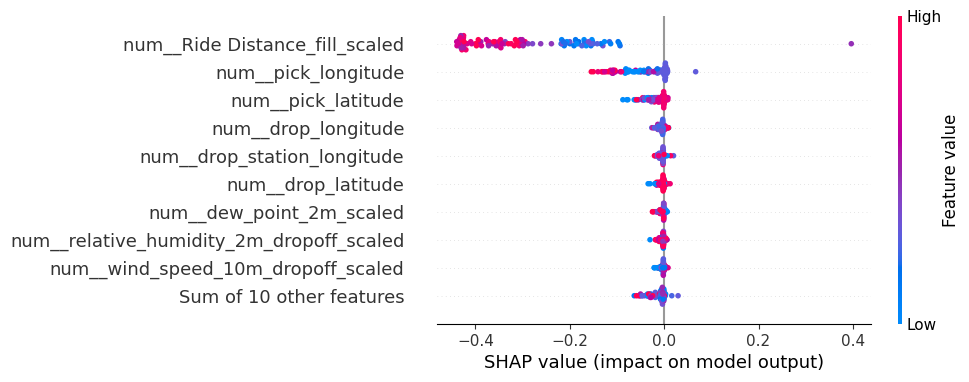

In [91]:
classify_vis_obj.beeswarm_plot(
    test_shap_values[:,:,0],
    figsize=(7,4)
    )